# car dhekho


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#Loading Data
df = pd.read_csv("car data.csv")

In [4]:
df

,Car_Name,company,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,maruti suzuki,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,maruti suzuki,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,maruti suzuki,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,maruti suzuki,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,maruti suzuki,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...,...
296,city,honda,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,honda,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,honda,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,honda,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
#Summary of data
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
#structure of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   company        301 non-null    object 
 2   Year           301 non-null    int64  
 3   Selling_Price  301 non-null    float64
 4   Present_Price  301 non-null    float64
 5   Kms_Driven     301 non-null    int64  
 6   Fuel_Type      301 non-null    object 
 7   Seller_Type    301 non-null    object 
 8   Transmission   301 non-null    object 
 9   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 23.6+ KB


In [7]:
#checking missing values
df.isnull().sum()

Car_Name         0
company          0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

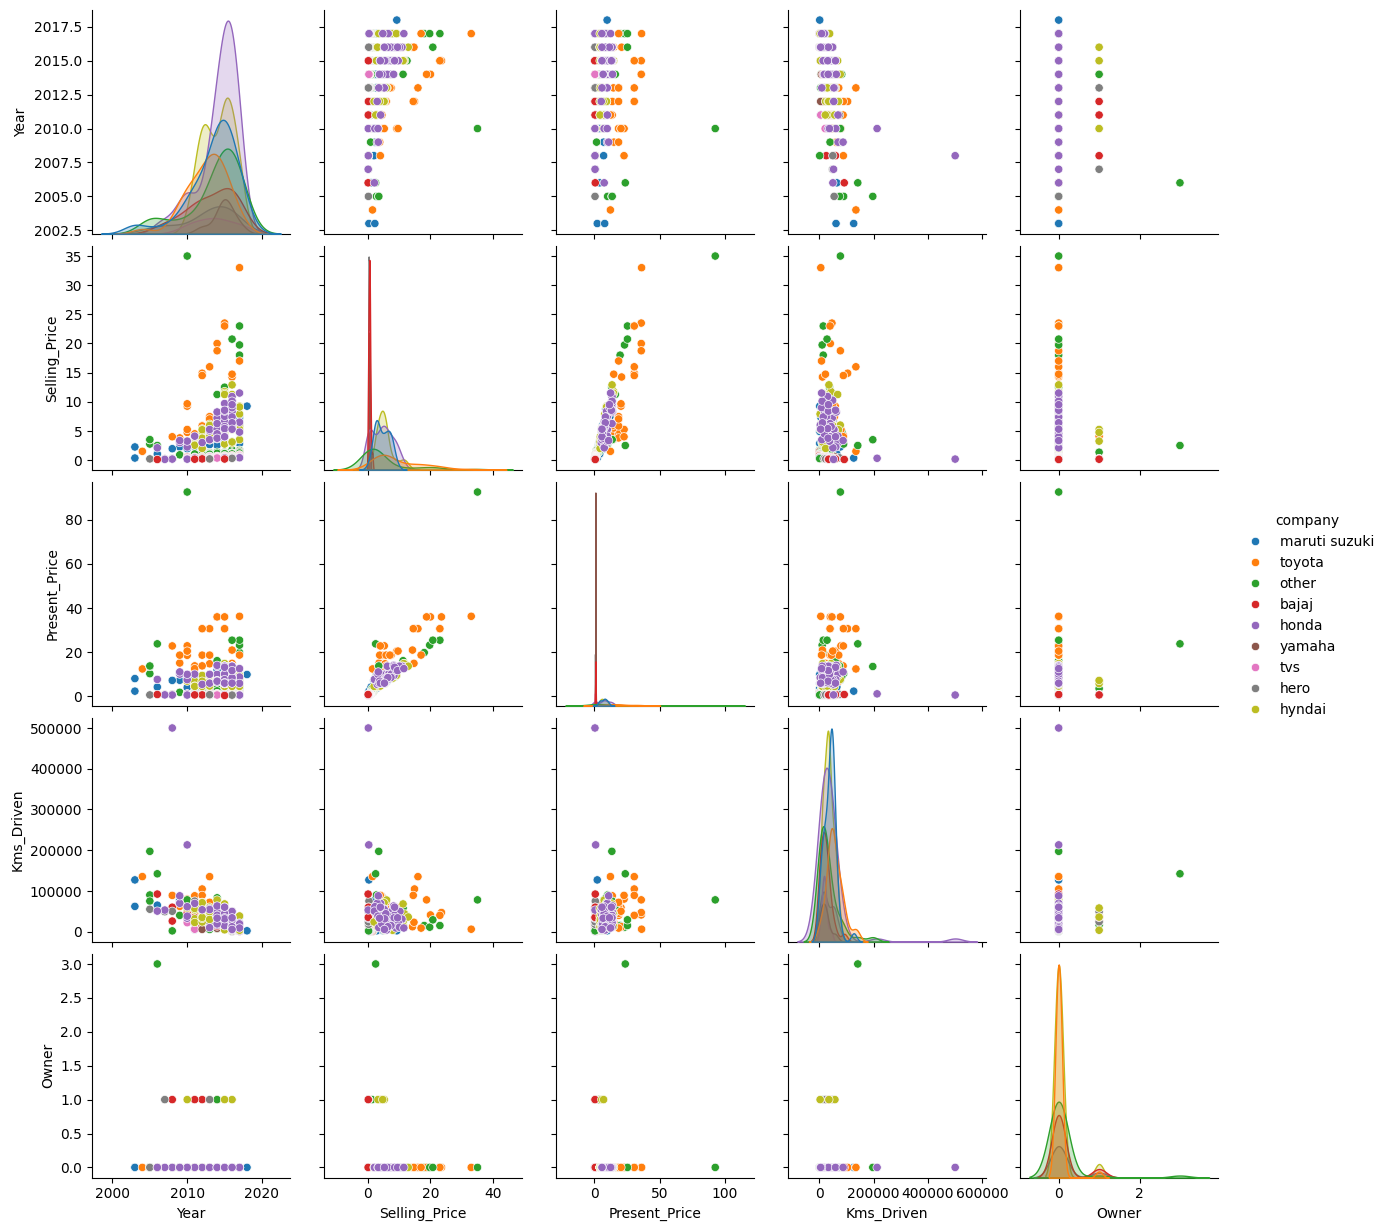

In [8]:
#EDA(exploratory data analysis
sns.pairplot(df, hue='company', diag_kind='kde')
plt.show()

In [9]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:\n", categorical_cols)

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

Categorical Columns:
 Index(['Car_Name', 'company', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')


In [10]:
df

,Car_Name,company,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,90,4,2014,3.35,5.59,27000,2,0,1,0
1,93,4,2013,4.75,9.54,43000,1,0,1,0
2,68,4,2017,7.25,9.85,6900,2,0,1,0
3,96,4,2011,2.85,4.15,5200,2,0,1,0
4,92,4,2014,4.60,6.87,42450,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
296,69,2,2016,9.50,11.60,33988,1,0,1,0
297,66,2,2015,4.00,5.90,60000,2,0,1,0
298,69,2,2009,3.35,11.00,87934,2,0,1,0
299,69,2,2017,11.50,12.50,9000,1,0,1,0


In [11]:
#feature scaling
scaler = StandardScaler()
df[['Car_Name', 'company', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven','Fuel_Type']] = scaler.fit_transform(df[['Car_Name', 'company', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven','Fuel_Type']])

In [12]:
df

,Car_Name,company,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,1.074323,0.285023,0.128897,-0.258416,-0.236215,-0.256224,0.500183,0,1,0
1,1.191828,0.285023,-0.217514,0.017481,0.221505,0.155911,-1.852241,0,1,0
2,0.212627,0.285023,1.168129,0.510154,0.257427,-0.773969,0.500183,0,1,0
3,1.309332,0.285023,-0.910335,-0.356950,-0.403079,-0.817758,0.500183,0,1,0
4,1.152659,0.285023,0.128897,-0.012079,-0.087890,0.141743,-1.852241,0,1,0
...,...,...,...,...,...,...,...,...,...,...
296,0.251795,-0.736309,0.821718,0.953559,0.460214,-0.076225,-1.852241,0,1,0
297,0.134290,-0.736309,0.475308,-0.130321,-0.200292,0.593804,0.500183,0,1,0
298,0.251795,-0.736309,-1.603156,-0.258416,0.390687,1.313340,0.500183,0,1,0
299,0.251795,-0.736309,1.168129,1.347698,0.564504,-0.719876,-1.852241,0,1,0


In [13]:
#train test split
X = df.drop('Selling_Price', axis = 1) #random_state(42) states that each time u run the code data will be split in the same manner
y = df['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 42)

In [14]:
#Building multiple linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [16]:
# Evaluate multiple regression
y_pred_multiple = lr.predict(X_test)
print("Multiple Linear Regression R2:", r2_score(y_test, y_pred_multiple))
print("MAE:", mean_absolute_error(y_test, y_pred_multiple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multiple)))

Multiple Linear Regression R2: 0.8779659974905587
MAE: 0.2390275088843093
RMSE: 0.36084640766624404


In [19]:
#Feature engineering
poly = PolynomialFeatures(degree = 2, interaction_only=False, include_bias = False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#Ridge regression
ridge = Ridge(alpha= 1.0)
ridge.fit(X_train_poly, y_train)
y_pred_ridge = ridge.predict(X_test_poly)
print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))

# Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_poly, y_train)
y_pred_lasso = lasso.predict(X_test_poly)
print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))

Ridge Regression R2: 0.9748308091914655
Lasso Regression R2: 0.9701649380577584


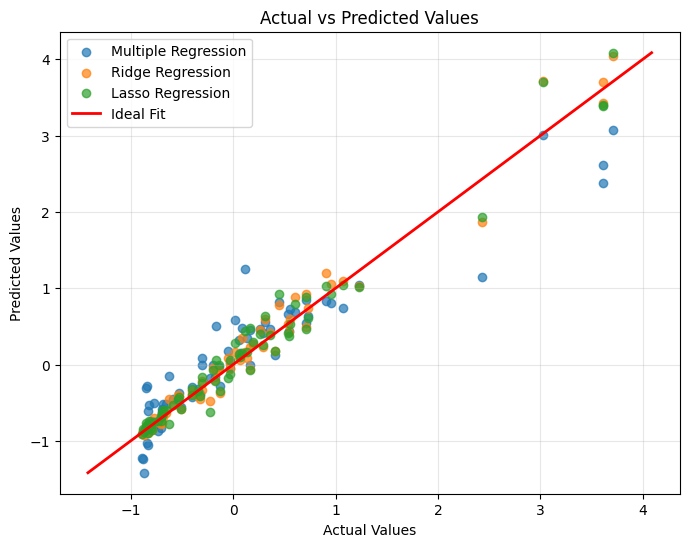

In [20]:
# Adjust the Ideal Fit Line to Extend Fully
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multiple, label='Multiple Regression', alpha=0.7)
plt.scatter(y_test, y_pred_ridge, label='Ridge Regression', alpha=0.7)
plt.scatter(y_test, y_pred_lasso, label='Lasso Regression', alpha=0.7)

# Extend the ideal fit line across the full range of the plot
min_val = min(y_test.min(), y_pred_multiple.min(), y_pred_ridge.min(), y_pred_lasso.min())
max_val = max(y_test.max(), y_pred_multiple.max(), y_pred_ridge.max(), y_pred_lasso.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Ideal Fit', linewidth=2)

# Add titles, labels, and legend
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
